# Deterministic Rules vs. GPT-2 Model

Head-to-head on the synthetic test set. The rules emit 3 classes (match/non_match/review) while the model is binary, so we compare:
1. **Model on all pairs** (its native task).
2. **Model vs. Rules on the rules' decided subset** (apples-to-apples — exclude the pairs the rules send to review).
3. **Model behavior on the review zone** — where the rules abstain and the model is forced to guess.

Rules-only EDA lives in `rules_eda.ipynb`.

In [1]:
import os, sys
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

REPO_ROOT = os.getcwd()
while not os.path.exists(os.path.join(REPO_ROOT, 'loo.py')) and os.path.dirname(REPO_ROOT) != REPO_ROOT:
    REPO_ROOT = os.path.dirname(REPO_ROOT)
sys.path.insert(0, REPO_ROOT); sys.path.insert(0, os.path.join(REPO_ROOT, 'deterministic_rules'))
import rules_alliance as R
pd.set_option('display.max_columns', None); pd.set_option('display.width', 140); sns.set_theme(style='whitegrid')

TEST_CSV  = os.path.join(REPO_ROOT, 'data', 'synthetic', 'synthetic_test_v3.csv')
MODEL_CSV = os.path.join(REPO_ROOT, 'data', 'synthetic', 'synthetic_test_predictions_anymatch_alliance_ft_v3.csv')

# rule predictions
scored = R.classify_df(R.load_paired_csv(TEST_CSV))
scored['label'] = scored['label'].astype(int)
# model predictions
model = pd.read_csv(MODEL_CSV, dtype={'PATID_A':'string','PATID_B':'string'})
m = model[['PATID_A','PATID_B','pred','match_prob']].rename(columns={'pred':'model_pred','match_prob':'model_prob'})
j = scored.merge(m, on=['PATID_A','PATID_B'], how='left')
j['model_pred'] = j['model_pred'].astype('Int64')
print(f"{len(j)} pairs  |  missing model preds: {int(j['model_pred'].isna().sum())}")
j[['PATID_A','PATID_B','label','case_type','rule_pred','rule_id','model_pred','model_prob']].head()

10000 pairs  |  missing model preds: 0


,PATID_A,PATID_B,label,case_type,rule_pred,rule_id,model_pred,model_prob
0,S000098581,S000098582,0,NM-HARD-DOB+LASTNAME,non_match,R-DEMO-NAMEDIFF,0,2.062890e-07
1,S000096321,S000096322,0,NM-HARD-DOB,non_match,R-DEMO-NAMEDIFF,0,5.781440e-07
2,S000096671,S000096672,0,NM-HARD-ADDR,non_match,R-DEMO-NAMEDIFF,0,1.851565e-06
3,S000091705,S000091706,0,NM-HARD-ADDR+DOB,non_match,R-DEMO-NAMEDIFF,0,1.290627e-07
4,S000088389,S000088390,0,NM-HH-PARENT-CHILD,non_match,R-DEMO-NAMEDIFF,0,8.825406e-07


## 1. Model on ALL pairs (its native binary task)

               precision    recall  f1-score   support

non_match (0)     1.0000    0.9978    0.9989      8000
    match (1)     0.9911    1.0000    0.9955      2000

     accuracy                         0.9982     10000
    macro avg     0.9955    0.9989    0.9972     10000
 weighted avg     0.9982    0.9982    0.9982     10000



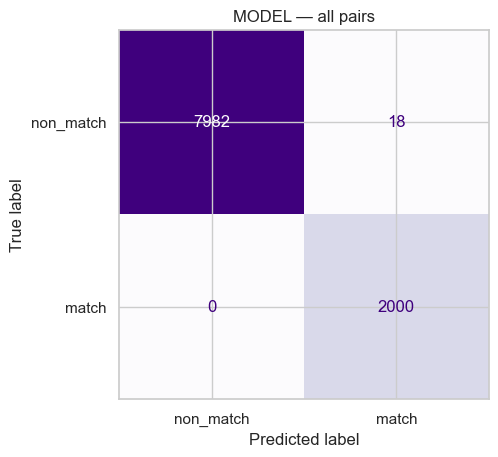

In [2]:
allm = j.dropna(subset=['model_pred']).copy(); allm['model_pred'] = allm['model_pred'].astype(int)
print(classification_report(allm['label'], allm['model_pred'], target_names=['non_match (0)','match (1)'], digits=4))
cm = confusion_matrix(allm['label'], allm['model_pred'], labels=[0,1])
ConfusionMatrixDisplay(cm, display_labels=['non_match','match']).plot(cmap='Purples', colorbar=False)
plt.title('MODEL — all pairs'); plt.show()

## 2. Apples-to-apples: Model vs. Rules on the rules' decided subset

Restrict to pairs the rules auto-decide (exclude review). Both systems are scored on the **same** pairs.

Decided subset: 9665 pairs (96.7% of all)

--- RULES (decided subset) ---
              precision    recall  f1-score   support

   non_match     0.9999    0.9994    0.9996      7840
       match     0.9973    0.9995    0.9984      1825

    accuracy                         0.9994      9665
   macro avg     0.9986    0.9994    0.9990      9665
weighted avg     0.9994    0.9994    0.9994      9665

--- MODEL (same subset) ---
              precision    recall  f1-score   support

   non_match     1.0000    0.9985    0.9992      7840
       match     0.9935    1.0000    0.9967      1825

    accuracy                         0.9988      9665
   macro avg     0.9967    0.9992    0.9980      9665
weighted avg     0.9988    0.9988    0.9988      9665



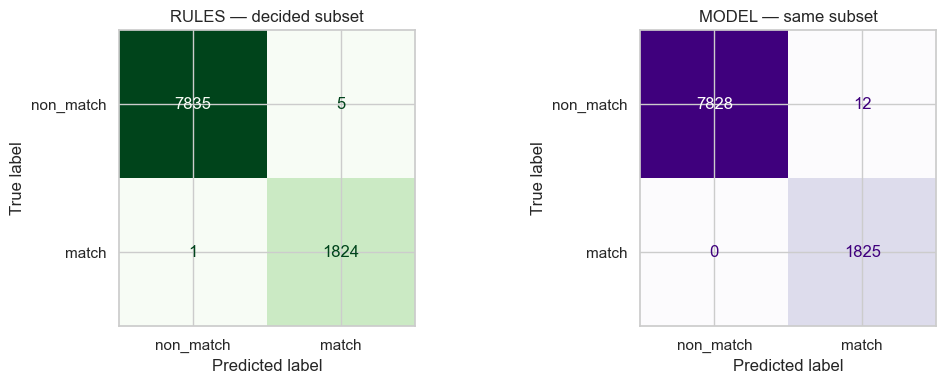

In [3]:
dec = j[(j['rule_pred'] != R.REVIEW) & j['model_pred'].notna()].copy()
dec['rule_bin'] = (dec['rule_pred'] == R.MATCH).astype(int)
dec['model_pred'] = dec['model_pred'].astype(int)
print(f'Decided subset: {len(dec)} pairs ({len(dec)/len(j):.1%} of all)\n')

print('--- RULES (decided subset) ---')
print(classification_report(dec['label'], dec['rule_bin'], target_names=['non_match','match'], digits=4))
print('--- MODEL (same subset) ---')
print(classification_report(dec['label'], dec['model_pred'], target_names=['non_match','match'], digits=4))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(dec['label'], dec['rule_bin'], labels=[0,1]), display_labels=['non_match','match']).plot(ax=ax[0], cmap='Greens', colorbar=False)
ax[0].set_title('RULES — decided subset')
ConfusionMatrixDisplay(confusion_matrix(dec['label'], dec['model_pred'], labels=[0,1]), display_labels=['non_match','match']).plot(ax=ax[1], cmap='Purples', colorbar=False)
ax[1].set_title('MODEL — same subset')
plt.tight_layout(); plt.show()

In [4]:
# side-by-side metric summary
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
def row(name, yt, yp):
    return dict(system=name, precision=precision_score(yt,yp,zero_division=0), recall=recall_score(yt,yp,zero_division=0),
                f1=f1_score(yt,yp,zero_division=0), mcc=matthews_corrcoef(yt,yp),
                false_matches=int(((yp==1)&(yt==0)).sum()), missed_matches=int(((yp==0)&(yt==1)).sum()))
summary = pd.DataFrame([
    row('rules (decided)',  dec['label'].values, dec['rule_bin'].values),
    row('model (decided)',  dec['label'].values, dec['model_pred'].values),
    row('model (all pairs)',allm['label'].values, allm['model_pred'].values),
]).set_index('system')
display(summary.round(4))

,precision,recall,f1,mcc,false_matches,missed_matches
system,,,,,,
rules (decided),0.9973,0.9995,0.9984,0.9980,5,1
model (decided),0.9935,1.0000,0.9967,0.9960,12,0
model (all pairs),0.9911,1.0000,0.9955,0.9944,18,0


## 3. Where they disagree (on the decided subset)

In [5]:
dec['agree'] = dec['rule_bin'] == dec['model_pred']
print(f"Agreement on decided subset: {dec['agree'].mean():.2%}  ({int((~dec['agree']).sum())} disagreements)\n")
disagree = dec[~dec['agree']]
print('Disagreement breakdown (who was right vs. truth):')
disagree = disagree.assign(rules_correct=disagree['rule_bin']==disagree['label'],
                           model_correct=disagree['model_pred']==disagree['label'])
display(pd.crosstab(disagree['rules_correct'], disagree['model_correct']))
display(pd.crosstab(disagree['case_type'], [disagree['rule_bin'], disagree['model_pred']]))

Agreement on decided subset: 99.86%  (14 disagreements)

Disagreement breakdown (who was right vs. truth):


model_correct,False,True
rules_correct,,
False,0,4
True,10,0


rule_bin,0,1
model_pred,1,0
case_type,,
M-PED-03,1,0
NM-COMMON-06,0,1
NM-HARD-ADDR+DOB,2,0
NM-HARD-ADDR+DOB+PHONE,1,0
NM-HARD-DOB,3,0
NM-HARD-DOB+LASTNAME,1,0
NM-HARD-DOB+LASTNAME+PHONE,0,2
NM-HARD-DOB+PHONE,1,0


## 4. Model behavior on the REVIEW zone

These are the pairs the rules refuse to auto-decide. The model has no abstain option — it must guess. This is where its decisions are least trustworthy on real data.

Review-zone pairs: 335  (true matches: 175, true non-matches: 160)

Model on the review zone:
              precision    recall  f1-score   support

   non_match     1.0000    0.9625    0.9809       160
       match     0.9669    1.0000    0.9831       175

    accuracy                         0.9821       335
   macro avg     0.9834    0.9812    0.9820       335
weighted avg     0.9827    0.9821    0.9821       335



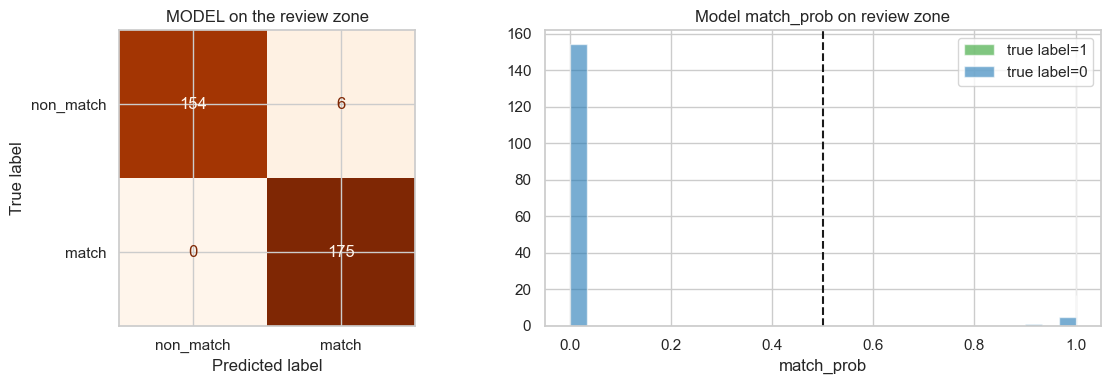

In [6]:
rev = j[(j['rule_pred']==R.REVIEW) & j['model_pred'].notna()].copy(); rev['model_pred']=rev['model_pred'].astype(int)
print(f'Review-zone pairs: {len(rev)}  (true matches: {int((rev.label==1).sum())}, true non-matches: {int((rev.label==0).sum())})\n')
print('Model on the review zone:')
print(classification_report(rev['label'], rev['model_pred'], target_names=['non_match','match'], digits=4))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix(rev['label'], rev['model_pred'], labels=[0,1]), display_labels=['non_match','match']).plot(ax=ax[0], cmap='Oranges', colorbar=False)
ax[0].set_title('MODEL on the review zone')
for lab, c in [(1,'#2ca02c'),(0,'#1f77b4')]:
    ax[1].hist(rev.loc[rev.label==lab,'model_prob'].dropna(), bins=30, alpha=0.6, color=c, label=f'true label={lab}')
ax[1].axvline(0.5, ls='--', c='k'); ax[1].set_title('Model match_prob on review zone'); ax[1].set_xlabel('match_prob'); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Disagreement examples

In [7]:
SHOW = ['first_name','middle_name','last_name','suffix','dob','ssn','ssn4','address','zip','phone','email']
def _v(x):
    return '' if (x is None or (isinstance(x,float) and pd.isna(x)) or str(x).lower() in ('nan','none','<na>')) else str(x)
def show(sub, k=4, title=''):
    print('='*96); print(f'{title}   (n={len(sub)})'); print('='*96)
    for _, r in sub.head(k).iterrows():
        mp = '' if pd.isna(r.get('model_prob')) else f"{r['model_prob']:.3f}"
        print(f"[{r.case_type}] label={r.label} | rules={r.rule_pred}({r.rule_id}) | model={int(r.model_pred)} (p={mp})")
        for f in SHOW:
            l, rr = _v(r.get(f+'_l')), _v(r.get(f+'_r'))
            if l or rr:
                print(f"    {f:11s}: {l:30s} | {rr:30s}{'' if l==rr else '   <-- differs'}")
        print()

# rules say non_match, model says match (rules avoided a model false-positive?)
show(disagree[(disagree.rule_bin==0)&(disagree.model_pred==1)], title='Rules=non_match, Model=match')
# rules say match, model says non_match
show(disagree[(disagree.rule_bin==1)&(disagree.model_pred==0)], title='Rules=match, Model=non_match')

Rules=non_match, Model=match   (n=11)
[NM-HARD-DOB+LASTNAME] label=0 | rules=non_match(R-DEMO-NAMEDIFF) | model=1 (p=0.996)
    first_name : JASMINE                        | WILLIAM                          <-- differs
    last_name  : WILLIAMS                       | WILLIAMS                      
    dob        : 2009-07-03                     | 2009-07-03                    
    ssn        :                                | 388474621                        <-- differs
    ssn4       :                                | 4621                             <-- differs
    address    : 11878 GRAND AVE                | 1082 HALSTED CT                  <-- differs
    zip        : 60640                          | 60623                            <-- differs
    phone      : 3123840016 7086995142          | 2243427968 7085771984 7736504808   <-- differs

[M-PED-03] label=1 | rules=non_match(R-DEMO-NAMEDIFF) | model=1 (p=1.000)
    first_name : ANA                            | JNA              